<a href="https://colab.research.google.com/github/Yaroslav-Maloshuk/ML/blob/main/%D0%9B%D0%A0_%E2%84%969_PCA_%D0%9C%D0%B0%D0%BB%D0%BE%D1%88%D1%83%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Автор: Малошук Ярослав Вікторович ФІТ 3-15

Був присутний на парі.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
path = kagglehub.dataset_download("brunogrisci/leukemia-gene-expression-cumida")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'leukemia-gene-expression-cumida' dataset.
Path to dataset files: /kaggle/input/leukemia-gene-expression-cumida


In [3]:
df = pd.read_csv(os.path.join(path, "Leukemia_GSE9476.csv"))
df

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,1438_at,1487_at,1494_f_at,1598_g_at,160020_at,1729_at,1773_at,177_at,179_at,1861_at,200000_s_at,200001_at,200002_at,200003_s_at,200004_at,200005_at,200006_at,200007_at,200008_s_at,200009_at,200010_at,200011_s_at,200012_x_at,200013_at,200014_s_at,200015_s_at,200016_x_at,200017_at,...,AFFX-LysX-M_at,AFFX-M27830_3_at,AFFX-M27830_5_at,AFFX-M27830_M_at,AFFX-PheX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-r2-Bs-dap-3_at,AFFX-r2-Bs-dap-5_at,AFFX-r2-Bs-dap-M_at,AFFX-r2-Bs-lys-3_at,AFFX-r2-Bs-lys-5_at,AFFX-r2-Bs-lys-M_at,AFFX-r2-Bs-phe-3_at,AFFX-r2-Bs-phe-5_at,AFFX-r2-Bs-phe-M_at,AFFX-r2-Bs-thr-3_s_at,AFFX-r2-Bs-thr-5_s_at,AFFX-r2-Bs-thr-M_s_at,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Ec-bioB-5_at,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-Hs18SrRNA-3_s_at,AFFX-r2-Hs18SrRNA-5_at,AFFX-r2-Hs18SrRNA-M_x_at,AFFX-r2-Hs28SrRNA-3_at,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,4.664924,4.069624,7.074283,7.438073,6.821832,8.360211,7.587744,7.238501,5.734401,5.865721,9.295104,6.636996,9.755541,10.212504,12.407251,12.977283,10.949410,10.611486,11.382053,11.342892,10.302405,11.285861,12.523325,9.140868,12.844328,12.596627,10.326540,9.213715,12.604468,12.373271,...,4.568103,7.619534,8.343389,9.732518,6.099298,4.000511,3.787068,3.629474,3.913462,3.827702,4.029777,3.768196,4.092088,4.389022,3.898779,4.097232,4.517700,5.364897,4.280552,7.466814,7.071335,7.800091,8.668454,8.682131,10.706493,10.833865,7.726919,7.789713,6.321700,9.614230,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,5.171835,4.299875,7.142594,7.524391,7.130389,8.415714,7.583873,7.313870,5.976084,6.164710,9.446879,6.599872,9.423754,10.010801,12.411276,12.758434,10.451503,10.176835,10.666105,10.748283,9.705252,10.860936,11.900255,8.879454,12.775880,12.370225,9.622328,8.922037,12.300125,11.983417,...,4.639792,7.439936,7.439254,9.425794,6.107730,4.120106,3.834826,3.793323,3.805608,3.713036,4.632187,3.742746,4.193864,4.730004,3.824465,4.013561,4.585058,5.282592,4.295605,7.121819,6.794680,7.546754,8.619323,8.779505,10.078617,10.064735,6.978360,6.604256,5.531432,8.048438,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,4.775709,4.148363,7.078472,7.594000,6.979558,8.443395,7.641496,7.174561,5.955769,6.033188,9.341037,6.181278,9.856414,10.427438,12.357374,12.705206,11.032528,10.490721,10.852178,10.968982,10.071129,11.106406,12.228392,9.041621,12.729899,12.483352,9.723135,9.444384,12.438289,12.139090,...,4.587928,7.452421,6.067374,9.157064,6.143191,4.025417,3.758135,3.808717,3.832210,3.738326,4.102777,3.606323,4.129521,4.609007,3.691161,4.085744,4.478975,5.133186,4.316817,7.391692,6.865575,7.622999,8.628905,8.693501,10.623787,10.677363,7.094257,6.136596,5.097074,6.467669,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,4.829844,4.075494,7.196617,7.693270,7.070565,8.603658,7.824054,7.167371,6.061403,5.910305,9.380237,6.010667,9.487192,10.029003,12.273741,12.813917,10.954204,10.731867,11.161461,10.924930,9.849389,11.303500,12.366427,8.816796,12.748016,12.625464,9.609977,9.226519,12.522540,12.182611,...,4.617188,7.851476,6.682794,9.763431,6.452152,4.174680,4.076435,3.889536,3.804042,3.723229,4.047662,3.802412,3.979890,4.560311,3.682983,4.207926,4.643757,5.249032,4.385304,8.115436,7.753750,8.498908,9.778520,9.970581,11.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Columns: 22285 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(22283), int64(1), object(1)
memory usage: 10.9+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
target = df["type"]
target.value_counts()

,count
type,
AML,26
PB,10
Bone_Marrow,10
PBSC_CD34,10
Bone_Marrow_CD34,8


In [7]:
data = df.drop(columns=["samples", "type"])
z_scores = data.apply(zscore).abs()
outliers_mask = z_scores > 3
outlier_fraction = outliers_mask.mean(axis=1)
outlier_indices = outlier_fraction[outlier_fraction > 0.2].index
df = df.drop(index=outlier_indices)
target = target.drop(index=outlier_indices)

In [8]:
df.shape

(64, 22285)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler().set_output(transform='pandas')
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
pca = PCA().set_output(transform="pandas").fit(X_train)

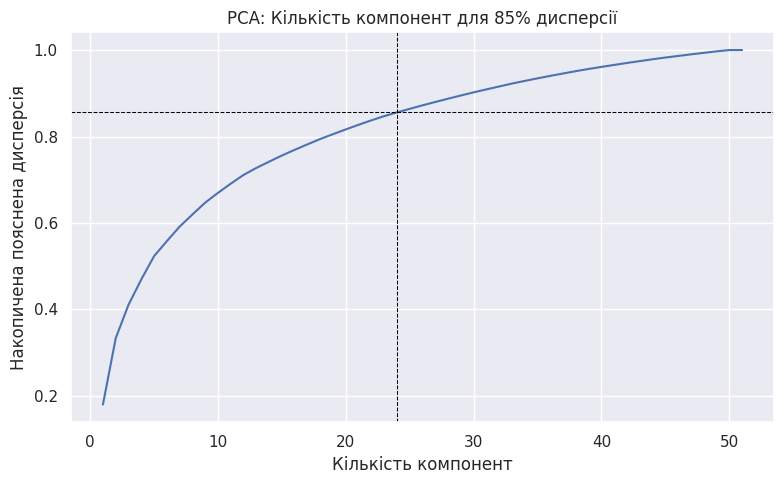

In [12]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(x=np.arange(1, len(explained_variance) + 1), y=explained_variance, ax=ax)

ax.set(
    xlabel='Кількість компонент',
    ylabel='Накопичена пояснена дисперсія',
    title='PCA: Кількість компонент для 85% дисперсії'
)

n_components = np.searchsorted(explained_variance, 0.85) + 1  # +1 бо індексація з 0

ax.axvline(x=n_components, color='black', linestyle='--', linewidth=0.75)
ax.axhline(y=explained_variance[n_components - 1], color='black', linestyle='--', linewidth=0.75)

plt.tight_layout()
plt.show()

In [13]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [14]:
X_train_pca.iloc[:, :n_components].head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23
13,16.820999,34.903574,-0.890093,11.339648,41.858329,-43.650248,19.498081,-38.811836,3.569116,-3.708797,-14.138809,-11.891569,-4.872889,-6.896811,-4.926885,-4.775903,-9.667523,-1.280651,12.311428,1.945766,-2.897287,-12.958723,-8.618061,4.344385
34,44.894760,-12.157780,-57.720991,53.716727,-62.184216,-22.503680,17.746703,3.415854,19.813474,21.489266,-22.813467,18.702033,-25.665226,51.232703,79.838325,-3.788930,15.092687,-29.132727,17.134900,-4.434168,-14.445294,-0.041625,-10.276779,0.389676
50,-24.682635,131.334127,9.749087,-3.021057,-19.243698,-6.702661,0.440195,29.895475,4.879099,4.985307,-12.523558,-22.489148,14.346044,-2.444943,0.839195,8.904300,-4.982312,3.954331,7.133173,4.702663,-6.966067,23.984453,-4.821261,-2.230078
3,40.891589,-64.783435,-16.635704,-27.814461,41.382949,-5.982859,-8.663965,39.164372,-1.307748,20.488950,-19.231874,-0.051875,-8.058505,0.408657,-8.783102,-2.645770,-6.764236,4.933173,44.976101,-11.261858,11.582371,-10.032525,7.644777,6.329901
17,15.649074,37.946291,15.427679,18.151486,43.914519,-32.950138,-0.674742,-22.158600,5.028498,-30.223438,-3.128411,16.894590,-6.792321,0.790474,0.487636,-7.279847,-1.405508,-3.530243,-5.739945,-0.903455,2.138695,5.399026,-3.720250,-5.876050


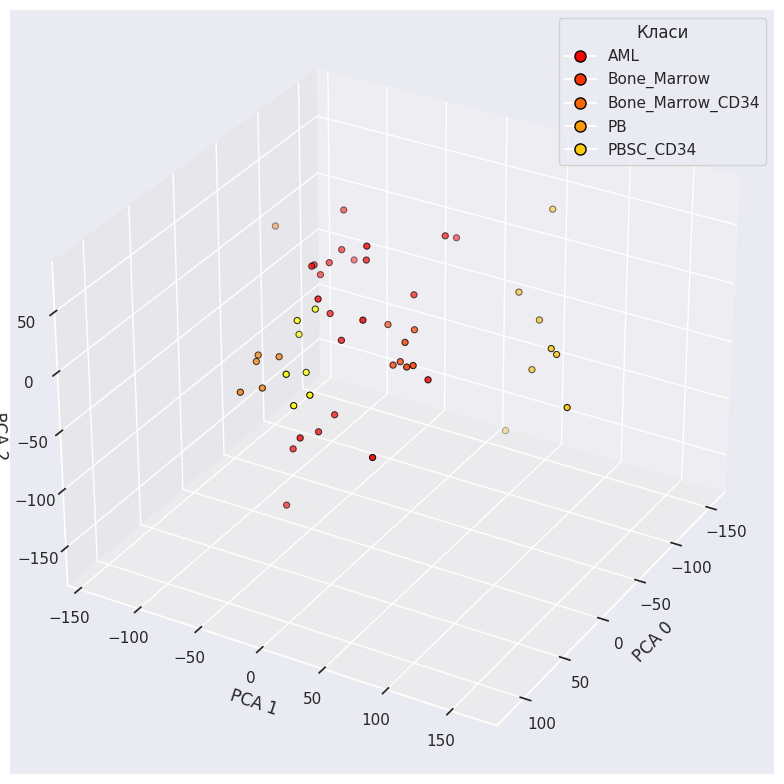

In [15]:
pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f"pca{i}" for i in range(X_train_pca.shape[1])],
    index=y_train.index
)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='3d')

scatter = ax.scatter3D(
    pca_df["pca0"],
    pca_df["pca1"],
    pca_df["pca2"],
    c=y_train_encoded,
    cmap='autumn',
    s=20,
    edgecolor='black',
    linewidth=0.75
)

ax.set_xlabel("PCA 0")
ax.set_ylabel("PCA 1")
ax.set_zlabel("PCA 2")
ax.view_init(elev=30, azim=30)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=plt.cm.autumn(i / len(label_encoder.classes_)),
           markeredgecolor='black', markersize=8)
    for i, label in enumerate(label_encoder.classes_)
]
ax.legend(handles=legend_elements, title="Класи", loc='best')

plt.tight_layout()
plt.show()

In [16]:
clf_full = GradientBoostingClassifier()
clf_full.fit(X_train, y_train)
pred_full = clf_full.predict(X_test)
score_full = accuracy_score(y_test, pred_full)
print(f"Model accuracy: {score_full:.1%}")

Model accuracy: 92.3%


In [17]:
clf_pca = GradientBoostingClassifier()
clf_pca.fit(X_train_pca.iloc[:, :n_components], y_train)
pred_pca = clf_pca.predict(X_test_pca.iloc[:, :n_components])
score_pca = accuracy_score(y_test, pred_pca)
print(f'Model accuracy (PCA): {score_pca:.1%}')

Model accuracy (PCA): 69.2%


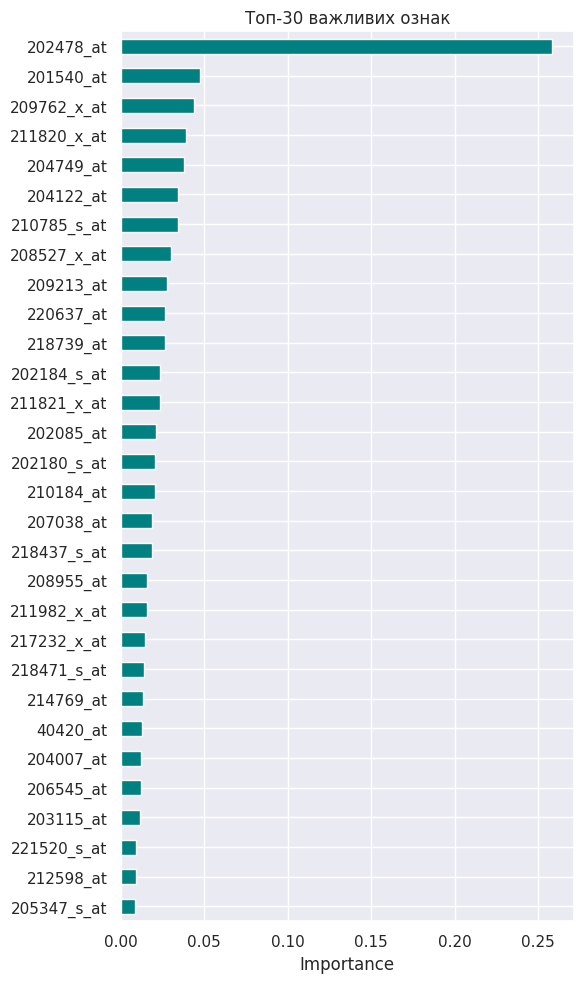

In [18]:
# Отримуємо важливість та обираємо топ-30 ознак
importances = pd.Series(
    data=clf_full.feature_importances_,
    index=X_train.columns
)

top_features = importances.sort_values(ascending=False).head(30)

# Побудова горизонтального barplot
plt.figure(figsize=(6, 10))
top_features.sort_values().plot.barh(color='teal')
plt.title("Топ-30 важливих ознак")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
nonzero = importances[importances > 0]
top = nonzero.sort_values(ascending=False).head(30)

plt.figure(figsize=(6, 10))
top.sort_values().plot.barh()
plt.title("Топ важливих ознак")
plt.tight_layout()
plt.show()

# Висновки
Після очищення даних видалено сильні викиди, що робить датасет більш надійним для моделювання. PCA показало, що близько 85% дисперсії можна пояснити з невеликою кількістю компонент, і 3D-візуалізація підтвердила розділення класів. Gradient Boosting показав високу точність як на повних даних, так і на PCA-компонентах, а аналіз важливості ознак виділив топ-30 генів, що найбільше впливають на класифікацію.